In [13]:
import os
import copy
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from pytorch_fid import fid_score

In [14]:
#set random seed function
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
#set random seed
set_seed(42)

In [15]:
#choose cpu/gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
#load and transform data
#transform part
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])
#load part
dataset = datasets.CIFAR10(
    root='./data(CIFAR10)', train=True, download=False, transform=transform
)

In [17]:
#loader data
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

In [18]:
#load Train-Loop
%run Train-Loop.ipynb

In [19]:
#load evaluation
%run Evaluation.ipynb

In [20]:
#initialize model
model = UNet().to(device)
ema = EMA(model, decay=0.9995)
#initialize optimizer
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0)

In [ ]:
## run train loop
loss_list, sigma_log_list, FID_list = train_loop(model, ema, optimizer, max_steps=60000, loader=loader)

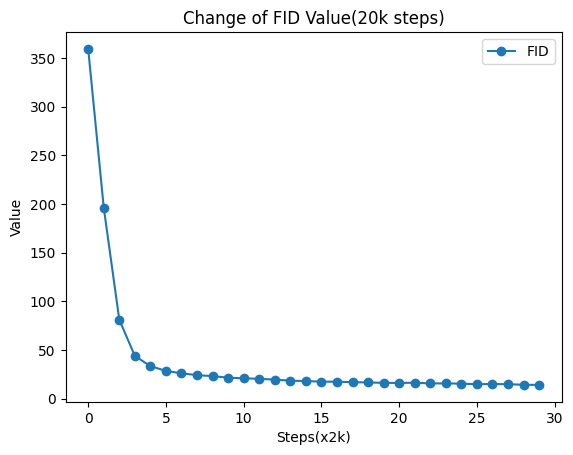

In [20]:
#show the distribution of FID value
plt.figure()
plt.plot(FID_list, marker='o', label='FID')
plt.xlabel('Steps(x2k)')
plt.ylabel('Value')
plt.title('Change of FID Value(20k steps)')
plt.legend(loc='best')
plt.show()

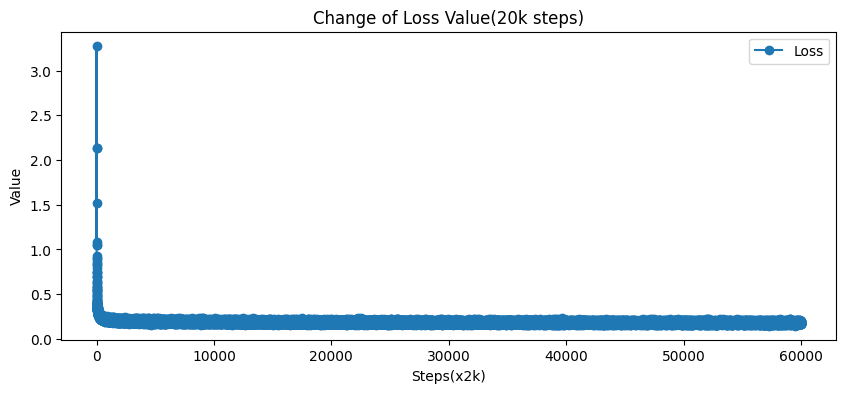

In [21]:
#show the distribution of loss value
plt.figure(figsize=(10, 4))
plt.plot(loss_list, marker='o', label='Loss')
plt.xlabel('Steps(x2k)')
plt.ylabel('Value')
plt.title('Change of Loss Value(20k steps)')
plt.legend(loc='best')
plt.show()